### 1. Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 2. basic processing

In [2]:

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

DATA_PATH = "../../data/processed/consolidated_dataframe_withbiovars.csv"

# Load data
consolidated_dataframe_withbiovars = pd.read_csv(DATA_PATH)
print(f"Records: {len(consolidated_dataframe_withbiovars):,}")
print(f"Columns: {list(consolidated_dataframe_withbiovars.columns)}")
print(consolidated_dataframe_withbiovars.head())


Records: 5,100
Columns: ['District', 'Month', 'Cases', 'Year', 'YearMonth', 'Precipitation_mm', 'Temp_Min_C', 'Temp_Max_C', 'Soil_Moisture_0_7cm', 'MRiceArea', 'MRiceYield', 'SRiceArea', 'SRiceYield', 'Population', 'Households', 'mean_temp', 'BIO1', 'BIO2', 'BIO3', 'BIO4', 'BIO5', 'BIO6', 'BIO7', 'BIO8', 'BIO9', 'BIO10', 'BIO11', 'BIO12', 'BIO13', 'BIO14', 'BIO15', 'BIO16', 'BIO17', 'BIO18', 'BIO19']
  District  Month  Cases  Year YearMonth  Precipitation_mm  Temp_Min_C  \
0   Ampara      1      1  2008   2008-01        177.600000     19.8505   
1   Ampara      2      3  2008   2008-02        121.000000     18.9005   
2   Ampara      3      0  2008   2008-03        293.600000     21.8005   
3   Ampara      4      1  2008   2008-04        119.000010     23.0505   
4   Ampara      5      4  2008   2008-05         34.600002     24.3005   

   Temp_Max_C  Soil_Moisture_0_7cm MRiceArea  ...    BIO10      BIO11  \
0     29.6005             0.380341    64,490  ...  29.3005  24.642167   
1    

In [3]:
consolidated_dataframe_withbiovars.dtypes

District                object
Month                    int64
Cases                    int64
Year                     int64
YearMonth               object
Precipitation_mm       float64
Temp_Min_C             float64
Temp_Max_C             float64
Soil_Moisture_0_7cm    float64
MRiceArea               object
MRiceYield              object
SRiceArea               object
SRiceYield              object
Population               int64
Households               int64
mean_temp              float64
BIO1                   float64
BIO2                   float64
BIO3                   float64
BIO4                   float64
BIO5                   float64
BIO6                   float64
BIO7                   float64
BIO8                   float64
BIO9                   float64
BIO10                  float64
BIO11                  float64
BIO12                  float64
BIO13                  float64
BIO14                  float64
BIO15                  float64
BIO16                  float64
BIO17   

In [4]:

# Basic cleaning: ensure numeric columns are numeric
numeric_cols = [
    "Cases", "Precipitation_mm", "Temp_Min_C", "Temp_Max_C",
    "Soil_Moisture_0_7cm", "MRiceArea", "MRiceYield",
    "SRiceArea", "SRiceYield", "Population", "Households", "BIO1", "BIO2", "BIO3", "BIO4",
    "BIO5", "BIO6", "BIO7",
    "BIO8", "BIO9", "BIO10", "BIO11",
    "BIO12", "BIO13", "BIO14", "BIO15",
    "BIO16", "BIO17", "BIO18", "BIO19"
]


In [5]:
# Check the missing values
consolidated_dataframe_withbiovars[numeric_cols].isna().sum()


Cases                    0
Precipitation_mm         0
Temp_Min_C               0
Temp_Max_C               0
Soil_Moisture_0_7cm      0
MRiceArea                0
MRiceYield               0
SRiceArea              192
SRiceYield             192
Population               0
Households               0
BIO1                     0
BIO2                     0
BIO3                     0
BIO4                     0
BIO5                     0
BIO6                     0
BIO7                     0
BIO8                     0
BIO9                     0
BIO10                    0
BIO11                    0
BIO12                    0
BIO13                    0
BIO14                    0
BIO15                    0
BIO16                    0
BIO17                    0
BIO18                    0
BIO19                    0
dtype: int64

The Above are actually not missing values, those records were not there because actually there are no rice production in these data points. So, impute those with value 0

In [6]:
# Convert the numeric columns to float
for col in numeric_cols:
    if col in consolidated_dataframe_withbiovars.columns:
        consolidated_dataframe_withbiovars[col] = (
            consolidated_dataframe_withbiovars[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip() # remove spaces
            .replace({"-": 0,"nan": 0,"": 0,"_": 0,"NA": 0}) # replace dash, nan, empty, underscore and NA with 0
            .astype(float)
        )


# Check the data types again
consolidated_dataframe_withbiovars.dtypes


District                object
Month                    int64
Cases                  float64
Year                     int64
YearMonth               object
Precipitation_mm       float64
Temp_Min_C             float64
Temp_Max_C             float64
Soil_Moisture_0_7cm    float64
MRiceArea              float64
MRiceYield             float64
SRiceArea              float64
SRiceYield             float64
Population             float64
Households             float64
mean_temp              float64
BIO1                   float64
BIO2                   float64
BIO3                   float64
BIO4                   float64
BIO5                   float64
BIO6                   float64
BIO7                   float64
BIO8                   float64
BIO9                   float64
BIO10                  float64
BIO11                  float64
BIO12                  float64
BIO13                  float64
BIO14                  float64
BIO15                  float64
BIO16                  float64
BIO17   

### 3. outlier detection techniques

#### 3.1 distribution plots

In [7]:
categorical_columns = ["District"]

numerical_columns = ["Cases","Precipitation_mm","Temp_Min_C","Temp_Max_C","Soil_Moisture_0_7cm","MRiceArea","MRiceYield",
    "SRiceArea","SRiceYield","Population","Households", "BIO1", "BIO2", "BIO3", "BIO4",
    "BIO5", "BIO6", "BIO7",
    "BIO8", "BIO9", "BIO10", "BIO11",
    "BIO12", "BIO13", "BIO14", "BIO15",
    "BIO16", "BIO17", "BIO18", "BIO19"]

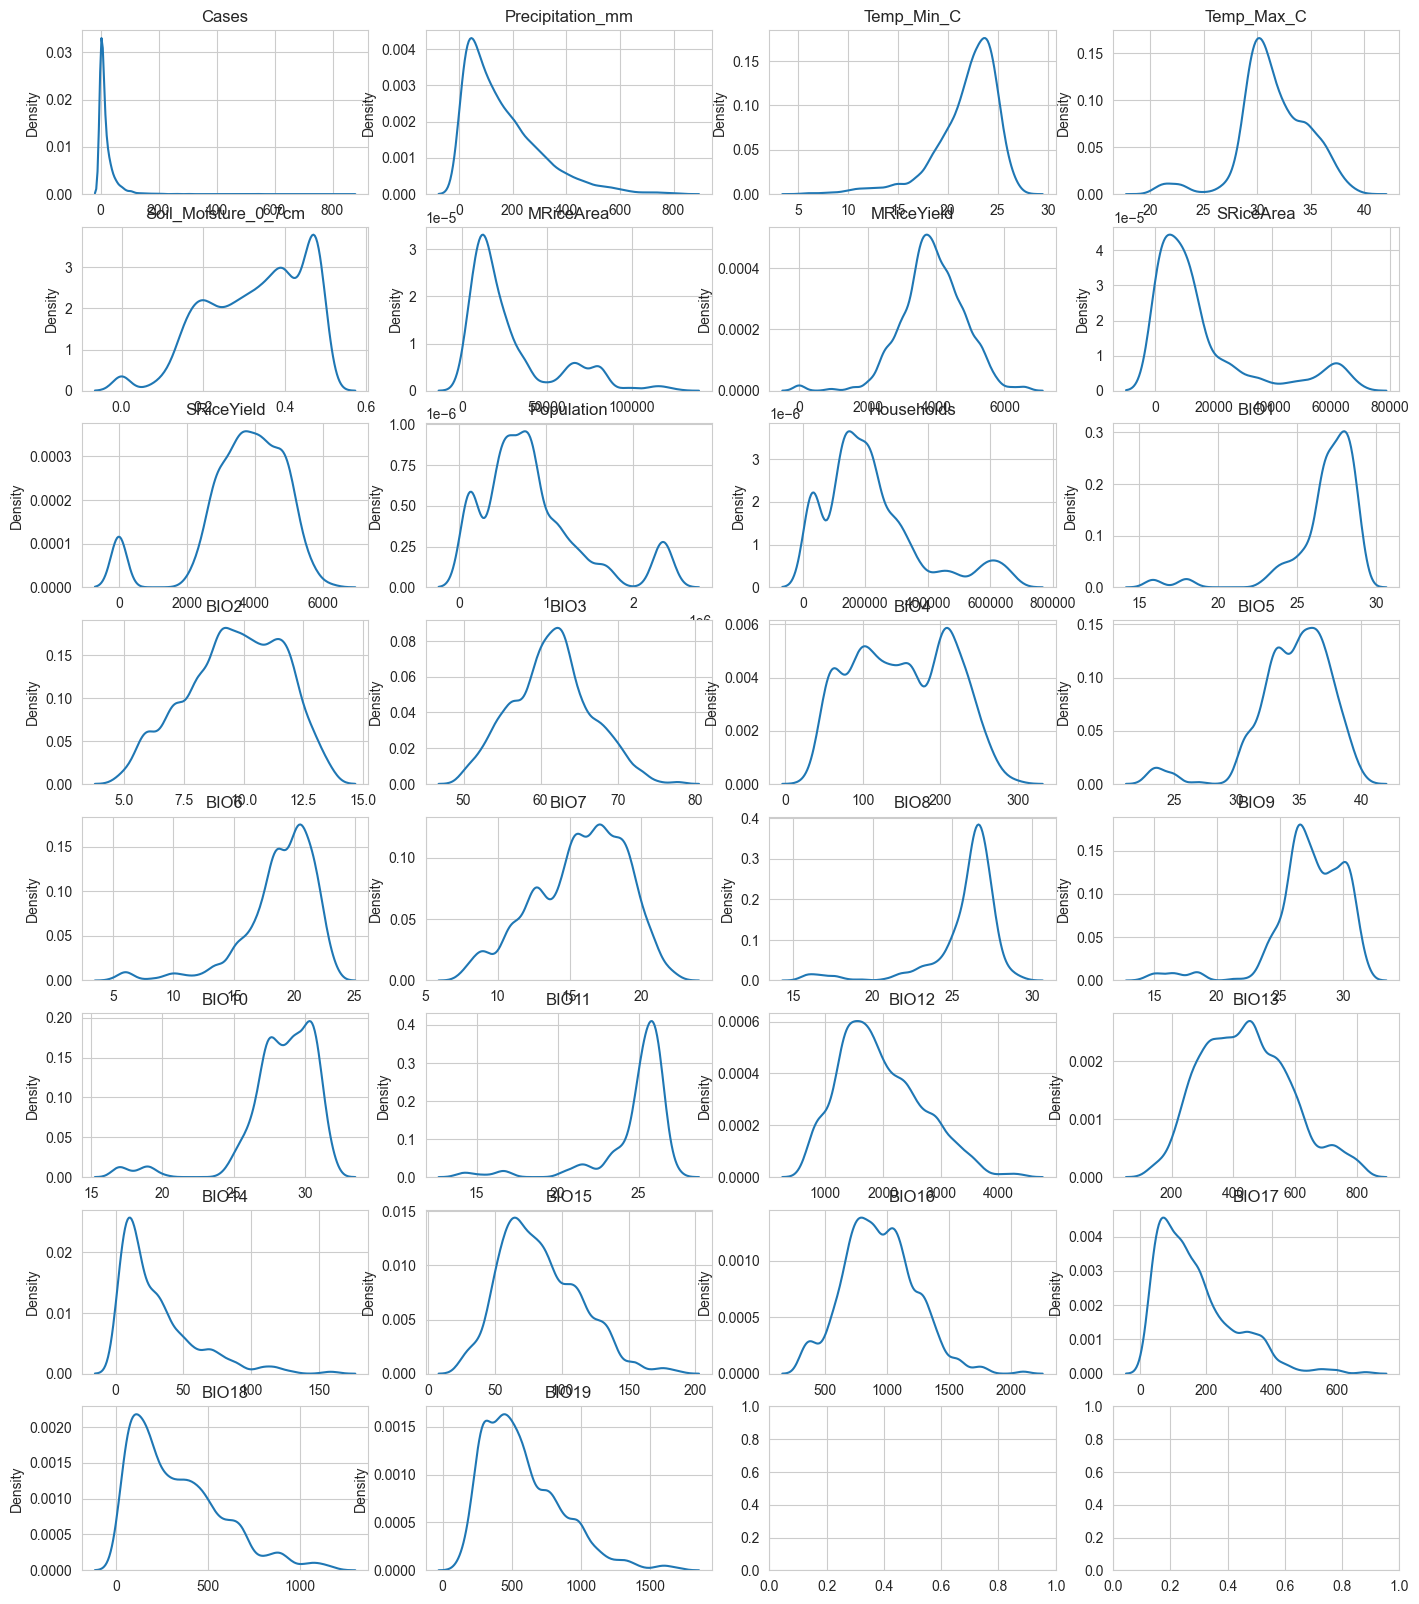

In [8]:
fig, axes = plt.subplots(8,4, figsize=(17,20))
axes = axes.flatten()

for idx, col in enumerate(numerical_columns):
    sns.kdeplot(
                data=consolidated_dataframe_withbiovars[col],
                ax=axes[idx]
                )
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

plt.show()

#### 3.2 box plots

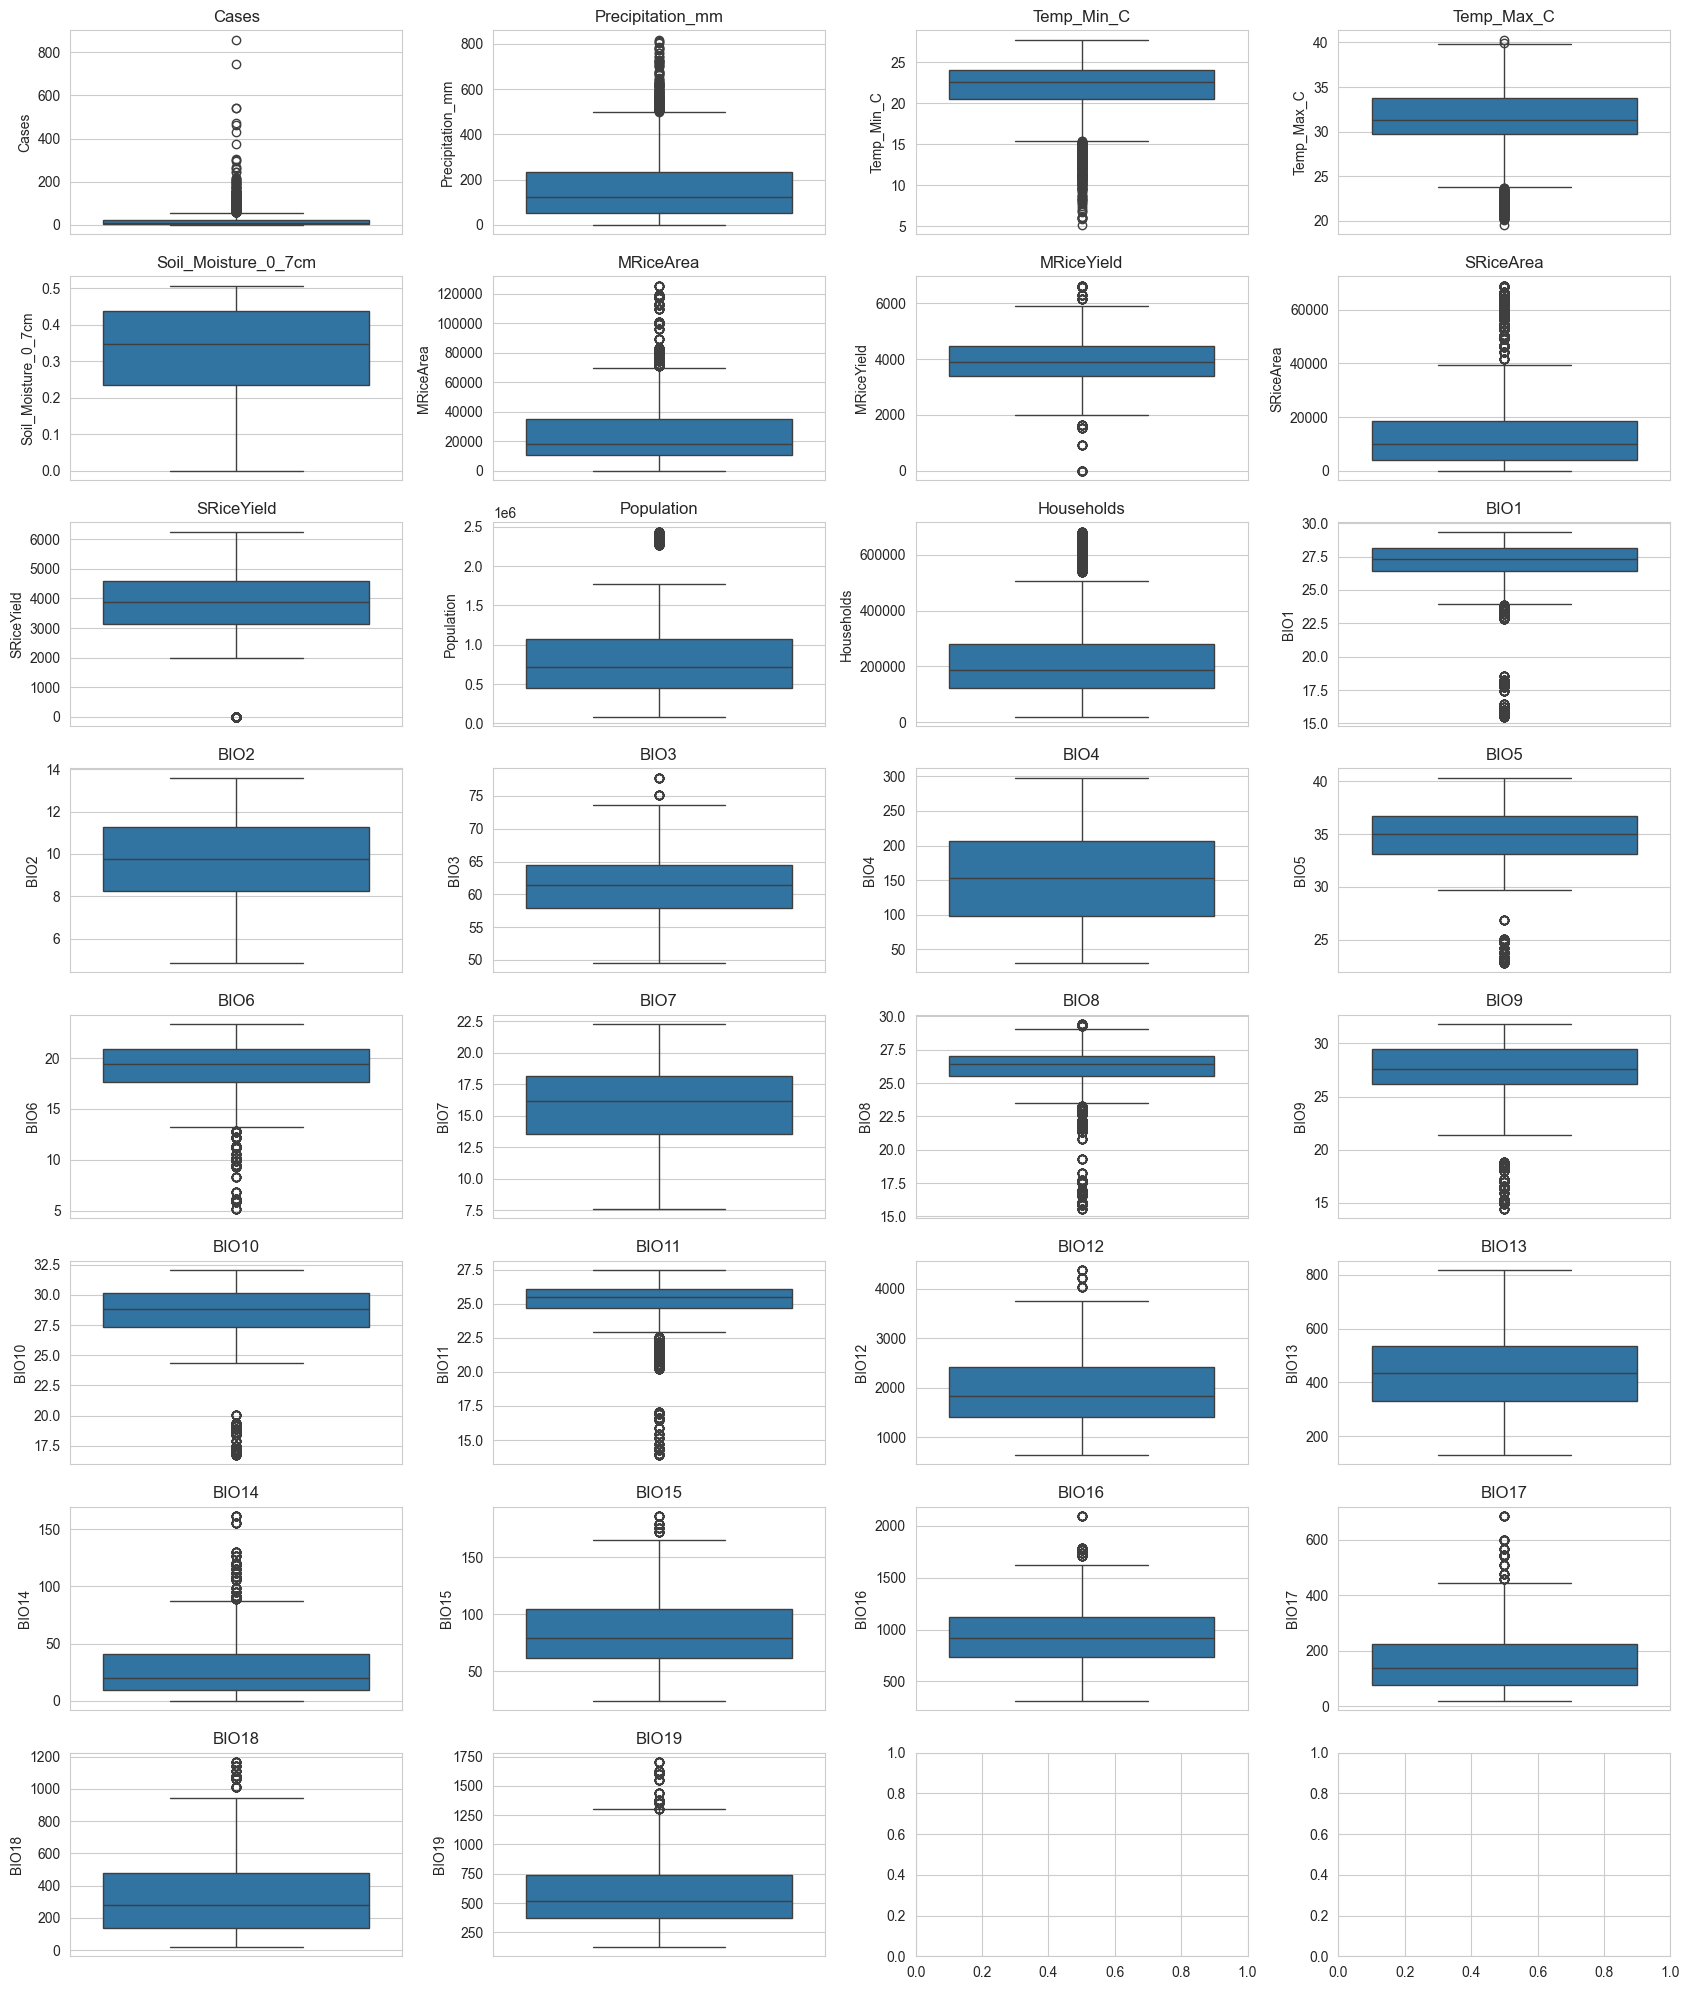

In [9]:
fig, axes = plt.subplots(8,4, figsize=(17,20))
axes = axes.flatten()

for idx, col in enumerate(numerical_columns):
    sns.boxplot(
                data=consolidated_dataframe_withbiovars[col],
                ax=axes[idx]
                )
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()

#### 3.3 empirical rule / 3-sigma rule

In [10]:
def find_anomaly(data):

    mean = data.mean()
    std = data.std()

    upper_bound = mean + (3 * std)
    lower_bound = mean - (3 * std)

    return (data > upper_bound) | (data < lower_bound)

In [11]:
for col in numerical_columns:
    n_outliers = find_anomaly(consolidated_dataframe_withbiovars[col]).sum()
    n_outlier_percentage = round(n_outliers / len(consolidated_dataframe_withbiovars), 3)
    print(f"{col} : {n_outliers} outliers ({n_outlier_percentage} %)")

Cases : 66 outliers (0.013 %)
Precipitation_mm : 73 outliers (0.014 %)
Temp_Min_C : 112 outliers (0.022 %)
Temp_Max_C : 89 outliers (0.017 %)
Soil_Moisture_0_7cm : 0 outliers (0.0 %)
MRiceArea : 84 outliers (0.016 %)
MRiceYield : 48 outliers (0.009 %)
SRiceArea : 0 outliers (0.0 %)
SRiceYield : 0 outliers (0.0 %)
Population : 0 outliers (0.0 %)
Households : 0 outliers (0.0 %)
BIO1 : 204 outliers (0.04 %)
BIO2 : 0 outliers (0.0 %)
BIO3 : 12 outliers (0.002 %)
BIO4 : 0 outliers (0.0 %)
BIO5 : 192 outliers (0.038 %)
BIO6 : 120 outliers (0.024 %)
BIO7 : 0 outliers (0.0 %)
BIO8 : 192 outliers (0.038 %)
BIO9 : 168 outliers (0.033 %)
BIO10 : 204 outliers (0.04 %)
BIO11 : 204 outliers (0.04 %)
BIO12 : 24 outliers (0.005 %)
BIO13 : 0 outliers (0.0 %)
BIO14 : 108 outliers (0.021 %)
BIO15 : 36 outliers (0.007 %)
BIO16 : 12 outliers (0.002 %)
BIO17 : 72 outliers (0.014 %)
BIO18 : 60 outliers (0.012 %)
BIO19 : 60 outliers (0.012 %)


As per the above percentages, the outlier percentage is much lower and in real scenarios, those types of data can be actually be there, also we need those to identify spikes.

Additionally, as I'm going to use mostly the tree based models, Those might handle these outliers.

In [12]:
mask = find_anomaly(consolidated_dataframe_withbiovars["Cases"])

print(
    consolidated_dataframe_withbiovars.loc[
        mask, ["District", "Year", "Cases"]
    ]
)

       District  Year  Cases
824     Colombo  2008  307.0
825     Colombo  2008  184.0
836     Colombo  2009  465.0
993     Colombo  2022  542.0
994     Colombo  2022  471.0
...         ...   ...    ...
4687  Ratnapura  2024  142.0
4688  Ratnapura  2024  134.0
4689  Ratnapura  2024  200.0
4690  Ratnapura  2024  210.0
4691  Ratnapura  2024  298.0

[66 rows x 3 columns]


### Save Processed Data
 - data\processed

In [13]:
##saved as a new csv
(consolidated_dataframe_withbiovars.to_csv('../../data/processed/preprocessed_consolidated_dataframe.csv',
                index=False))